<a href="https://colab.research.google.com/github/dhans2007/DEEP_LEARNING_LAB/blob/main/EXERCISE_4__PART_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

EX4

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
#DHANESH VC 24BAD018

IMG_SIZE = (160, 160)
BATCH_SIZE = 32
EPOCHS = 3
NUM_CLASSES = 6

TRAIN_DIR = "dataset/train"
VAL_DIR = "dataset/val"
TEST_DIR = "dataset/test"

In [ ]:
#LOAD DATASET

train_data = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_data = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_data = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_data.class_names

print("\nClasses:")
print(class_names)

Found 12632 files belonging to 6 classes.
Found 1402 files belonging to 6 classes.
Found 3000 files belonging to 6 classes.

Classes:
['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [ ]:

#SPEED OPTIMIZATION

AUTOTUNE = tf.data.AUTOTUNE

train_data = train_data.prefetch(AUTOTUNE)
val_data = val_data.prefetch(AUTOTUNE)
test_data = test_data.prefetch(AUTOTUNE)

#DATA AUGMENTATION

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.05)
])


In [ ]:
#LOAD PRE-TRAINED MOBILENETV2

base_model = tf.keras.applications.MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(160, 160, 3)
)

# Freeze pretrained layers
base_model.trainable = False

print("\nMobileNetV2 loaded successfully!")
print("Feature extraction layers frozen.")


MobileNetV2 loaded successfully!
Feature extraction layers frozen.


In [ ]:
#BUILD TRANSFER LEARNING MODEL

inputs = tf.keras.Input(shape=(160, 160, 3))

x = data_augmentation(inputs)

# MobileNetV2 preprocessing
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

# Pre-trained feature extractor
x = base_model(x, training=False)

# Reduce feature maps
x = tf.keras.layers.GlobalAveragePooling2D()(x)

# Prevent overfitting
x = tf.keras.layers.Dropout(0.2)(x)

# Final classification layer
outputs = tf.keras.layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

model = tf.keras.Model(inputs, outputs)

In [ ]:
#COMPILE

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("\nModel created successfully!")

#DISPLAY MODEL
model.summary()


Model created successfully!


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,265,670 (8.64 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
#TRAIN MODEL

print("\nStarting training...")

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS
)

#TEST MODEL

test_loss, test_accuracy = model.evaluate(test_data)

print("\n================================")
print("FINAL RESULTS")
print("================================")

print("Test Loss     :", round(test_loss, 4))
print("Test Accuracy :", round(test_accuracy * 100, 2), "%")


Starting training...
Epoch 1/3


c:\Users\HP\anaconda3\envs\tensorflow_env\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


395/395 ━━━━━━━━━━━━━━━━━━━━ 141s 345ms/step - accuracy: 0.6031 - loss: 1.0440 - val_accuracy: 0.8188 - val_loss: 0.5420
Epoch 2/3
395/395 ━━━━━━━━━━━━━━━━━━━━ 116s 293ms/step - accuracy: 0.8254 - loss: 0.4923 - val_accuracy: 0.8595 - val_loss: 0.3979
Epoch 3/3
395/395 ━━━━━━━━━━━━━━━━━━━━ 106s 268ms/step - accuracy: 0.8545 - loss: 0.4001 - val_accuracy: 0.8745 - val_loss: 0.3504
94/94 ━━━━━━━━━━━━━━━━━━━━ 19s 204ms/step - accuracy: 0.8897 - loss: 0.3330

FINAL RESULTS
Test Loss     : 0.333
Test Accuracy : 88.97 %


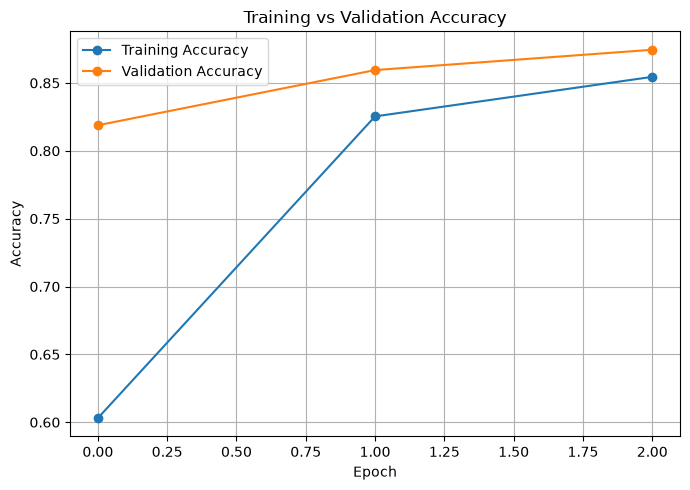

In [ ]:
#ACCURACY GRAPH

plt.figure(figsize=(7, 5))

plt.plot(
    history.history["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

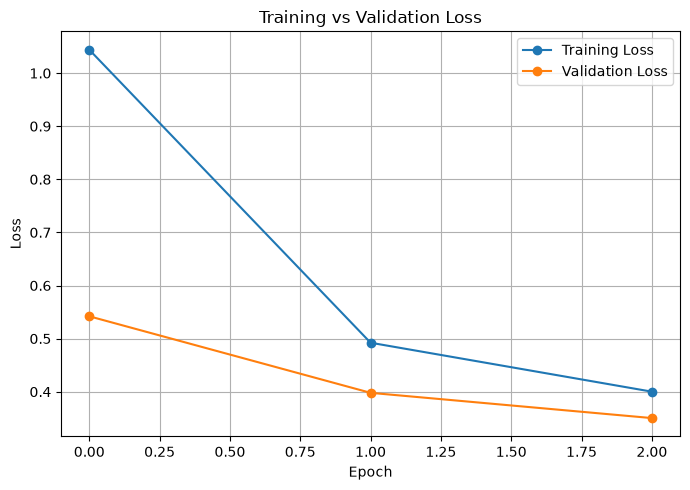

In [ ]:
#LOSS GRAPH

plt.figure(figsize=(7, 5))

plt.plot(
    history.history["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

In [ ]:
#SAVE MODEL

model.save("mobilenetv2_transfer_learning.keras")

print("\nModel saved as:")
print("mobilenetv2_transfer_learning.keras")

print("\nExperiment completed successfully!")


Model saved as:
mobilenetv2_transfer_learning.keras

Experiment completed successfully!
